In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import mlflow

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style("whitegrid")

In [3]:
path_raw = "../data/processed/hrss_clean_integrated_original_columns.csv"
df = pd.read_csv(path_raw)

# Rekonstruksi kolom operation_name dari operation_type untuk visualisasi di notebook ini
if 'operation_name' not in df.columns and 'operation_type' in df.columns:
    df['operation_name'] = df['operation_type'].map({0: 'standard', 1: 'optimized'})

print("Loaded shape:", df.shape)


Loaded shape: (46898, 20)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46898 entries, 0 to 46897
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               46898 non-null  float64
 1   I_w_BLO_Weg             46898 non-null  int64  
 2   O_w_BLO_power           46898 non-null  int64  
 3   O_w_BLO_voltage         46898 non-null  int64  
 4   I_w_BHL_Weg             46898 non-null  int64  
 5   O_w_BHL_power           46898 non-null  int64  
 6   O_w_BHL_voltage         46898 non-null  int64  
 7   I_w_BHR_Weg             46898 non-null  int64  
 8   O_w_BHR_power           46898 non-null  int64  
 9   O_w_BHR_voltage         46898 non-null  int64  
 10  I_w_BRU_Weg             46898 non-null  int64  
 11  O_w_BRU_power           46898 non-null  int64  
 12  O_w_BRU_voltage         46898 non-null  int64  
 13  I_w_HR_Weg              46898 non-null  int64  
 14  O_w_HR_power            46898 non-null

## Feature Engineering

In [4]:
# ============================================================
# FEATURE GROUPING
# ============================================================

weg_cols = [
    col for col in df.columns
    if "Weg" in col
]

power_cols = [
    col for col in df.columns
    if "power" in col
]

voltage_cols = [
    col for col in df.columns
    if "voltage" in col
]

print("Movement Features:")
print(weg_cols)

print("\nPower Features:")
print(power_cols)

print("\nVoltage Features:")
print(voltage_cols)

Movement Features:
['I_w_BLO_Weg', 'I_w_BHL_Weg', 'I_w_BHR_Weg', 'I_w_BRU_Weg', 'I_w_HR_Weg', 'I_w_HL_Weg']

Power Features:
['O_w_BLO_power', 'O_w_BHL_power', 'O_w_BHR_power', 'O_w_BRU_power', 'O_w_HR_power', 'O_w_HL_power']

Voltage Features:
['O_w_BLO_voltage', 'O_w_BHL_voltage', 'O_w_BHR_voltage', 'O_w_BRU_voltage', 'O_w_HR_voltage', 'O_w_HL_voltage']


### Total Power

In [5]:
# ============================================================
# FEATURE ENGINEERING - TOTAL POWER
# ============================================================

df["total_power"] = df[power_cols].sum(axis=1)

df[["total_power"]].head()

,total_power
0,14972
1,14972
2,14972
3,39207
4,39207


### AVG Voltage

In [6]:
# ============================================================
# FEATURE ENGINEERING - AVG VOLTAGE
# ============================================================

df["avg_voltage"] = df[voltage_cols].mean(axis=1)

df[["avg_voltage"]].head()

,avg_voltage
0,10.17
1,10.17
2,10.17
3,17.67
4,17.67


### Total Movement

In [7]:
# ============================================================
# FEATURE ENGINEERING - TOTAL MOVEMENT
# ============================================================

df["total_movement"] = df[weg_cols].abs().sum(axis=1)

df[["total_movement"]].head()

,total_movement
0,1401
1,1401
2,1401
3,1404
4,1404


### Power Efficiency

In [8]:
# ============================================================
# FEATURE ENGINEERING - POWER EFFICIENCY
# ============================================================

df["power_efficiency_ratio"] = (
    df["total_power"] /
    (df["total_movement"] + 1)
)

df[["power_efficiency_ratio"]].head()

,power_efficiency_ratio
0,10.68
1,10.68
2,10.68
3,27.91
4,27.91


### Rail Activity

In [9]:
# ============================================================
# FEATURE ENGINEERING - RAIL ACTIVITY
# ============================================================

rail_cols = [
    "I_w_HL_Weg",
    "I_w_HR_Weg"
]

df["rail_activity"] = (
    df[rail_cols].abs().sum(axis=1)
)

df[["rail_activity"]].head()

,rail_activity
0,0
1,0
2,0
3,0
4,0


In [10]:
df[
    [
        "Timestamp",
        "I_w_HL_Weg",
        "I_w_HR_Weg",
        "rail_activity"
    ]
].head(20)

,Timestamp,I_w_HL_Weg,I_w_HR_Weg,rail_activity
0,0.00,0,0,0
1,0.05,0,0,0
2,0.15,0,0,0
3,0.21,0,0,0
4,0.26,0,0,0
5,0.32,0,0,0
6,0.39,0,0,0
7,0.43,0,0,0
8,0.53,0,0,0
9,0.59,0,0,0


In [11]:
df[rail_cols].describe()

,I_w_HL_Weg,I_w_HR_Weg
count,46898.00,46898.00
mean,-408.57,-408.57
std,398.83,398.83
min,-833.00,-833.00
25%,-833.00,-833.00
50%,-330.00,-332.00
75%,0.00,0.00
max,0.00,0.00


In [12]:


(
    (df[rail_cols] == 0)
    .mean()
    * 100
)

I_w_HL_Weg   42.54
I_w_HR_Weg   42.52
dtype: float64

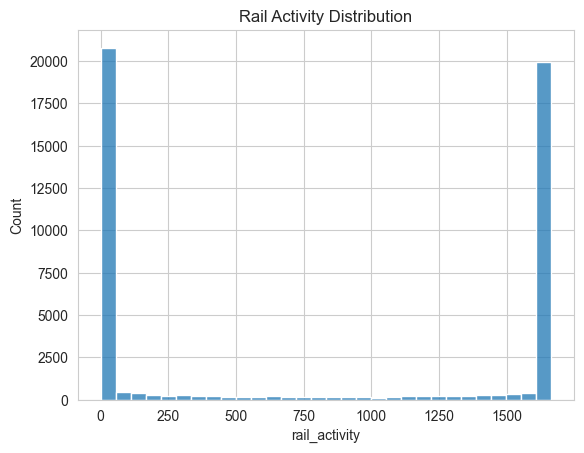

In [13]:
sns.histplot(df["rail_activity"], bins=30)

plt.title("Rail Activity Distribution")

plt.show()

In [14]:
(df["rail_activity"] == 0).mean()

0.42515672310119834

In [15]:
df[["I_w_HL_Weg", "I_w_HR_Weg"]].head()

,I_w_HL_Weg,I_w_HR_Weg
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [16]:
# ============================================================
# FEATURE ENGINEERING - CONVEYOR ACTIVITY
# ============================================================

conveyor_cols = [
    "I_w_BLO_Weg",
    "I_w_BHL_Weg",
    "I_w_BHR_Weg",
    "I_w_BRU_Weg"
]

df["conveyor_activity"] = (
    df[conveyor_cols].abs().sum(axis=1)
)

df[["conveyor_activity"]].head()

,conveyor_activity
0,1401
1,1401
2,1401
3,1404
4,1404


In [17]:
# ============================================================
# ENGINEERED FEATURE SUMMARY
# ============================================================

engineered_features = [
    "total_power",
    "avg_voltage",
    "total_movement",
    "power_efficiency_ratio",
    "rail_activity",
    "conveyor_activity"
]

df[engineered_features].describe()

,total_power,avg_voltage,total_movement,power_efficiency_ratio,rail_activity,conveyor_activity
count,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00
mean,46326.26,28.77,2456.25,24.11,817.14,1639.11
std,14218.57,24.66,1123.21,16.16,797.66,522.29
min,457.00,5.00,393.00,0.20,0.00,393.00
25%,36470.00,17.67,1484.00,13.83,0.00,1284.00
50%,45296.00,18.83,2317.00,20.23,663.00,1556.00
75%,56975.00,26.67,3386.00,29.41,1666.00,1944.00
max,112470.00,177.67,4500.00,127.17,1666.00,2834.00


In [18]:
# ============================================================
# TOTAL POWER COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="operation_name",
    y="total_power"
)

plt.title("Total Power Consumption Comparison")
plt.xlabel("Operation Type")
plt.ylabel("Total Power")

plt.show()

ValueError: Could not interpret value `operation_name` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

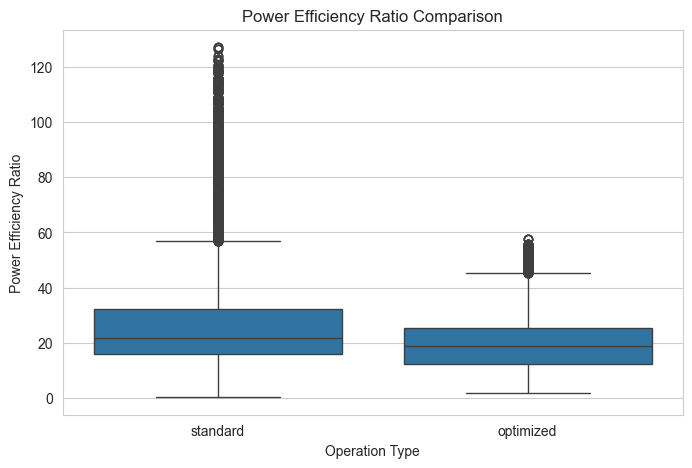

In [ ]:
# ============================================================
# POWER EFFICIENCY RATIO COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="operation_name",
    y="power_efficiency_ratio"
)

plt.title("Power Efficiency Ratio Comparison")
plt.xlabel("Operation Type")
plt.ylabel("Power Efficiency Ratio")

plt.show()

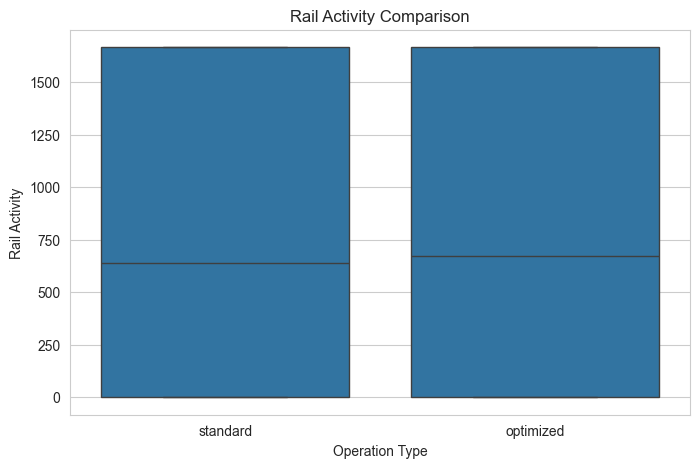

In [ ]:
# ============================================================
# RAIL ACTIVITY COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="operation_name",
    y="rail_activity"
)

plt.title("Rail Activity Comparison")
plt.xlabel("Operation Type")
plt.ylabel("Rail Activity")

plt.show()

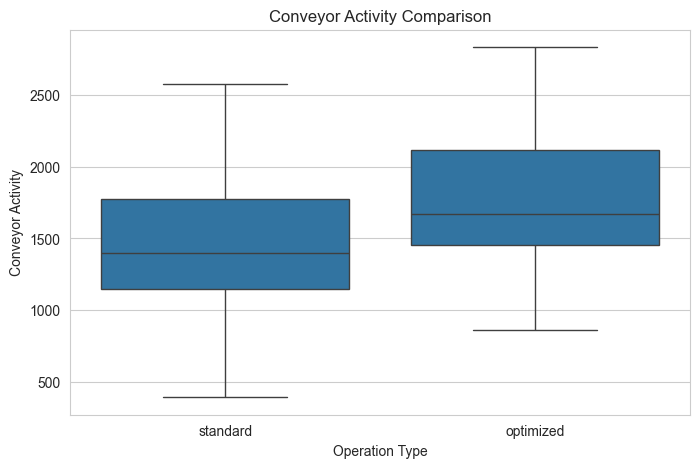

In [ ]:
# ============================================================
# CONVEYOR ACTIVITY COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="operation_name",
    y="conveyor_activity"
)

plt.title("Conveyor Activity Comparison")
plt.xlabel("Operation Type")
plt.ylabel("Conveyor Activity")

plt.show()

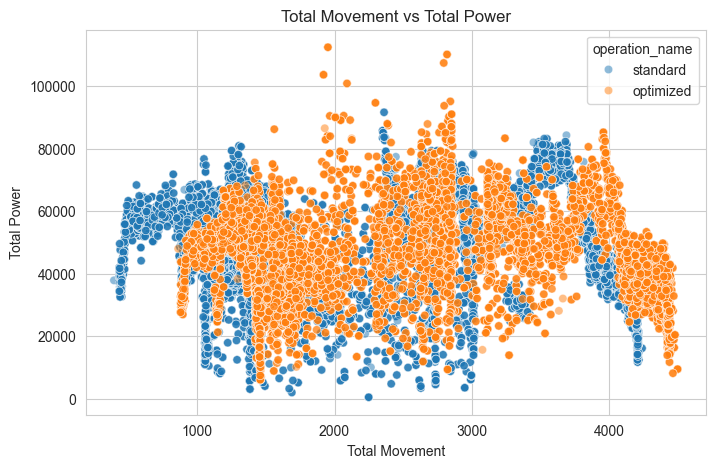

In [ ]:
# ============================================================
# MOVEMENT VS POWER RELATIONSHIP
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="total_movement",
    y="total_power",
    hue="operation_name",
    alpha=0.5
)

plt.title("Total Movement vs Total Power")
plt.xlabel("Total Movement")
plt.ylabel("Total Power")

plt.show()

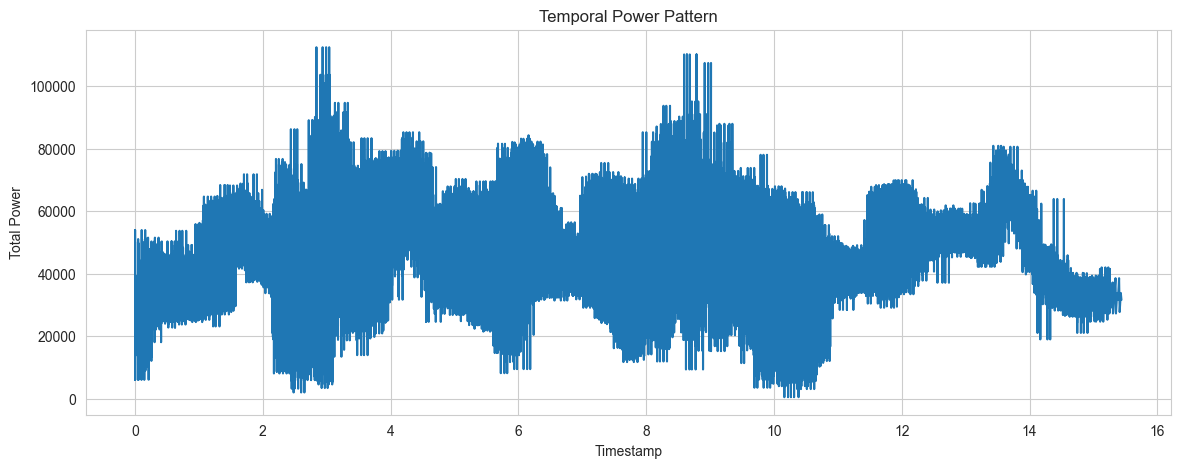

In [ ]:
# ============================================================
# TIMESTAMP EXPLORATION
# ============================================================

sample_df = df.sort_values("Timestamp")

plt.figure(figsize=(14,5))

plt.plot(
    sample_df["Timestamp"],
    sample_df["total_power"]
)

plt.title("Temporal Power Pattern")
plt.xlabel("Timestamp")
plt.ylabel("Total Power")

plt.show()

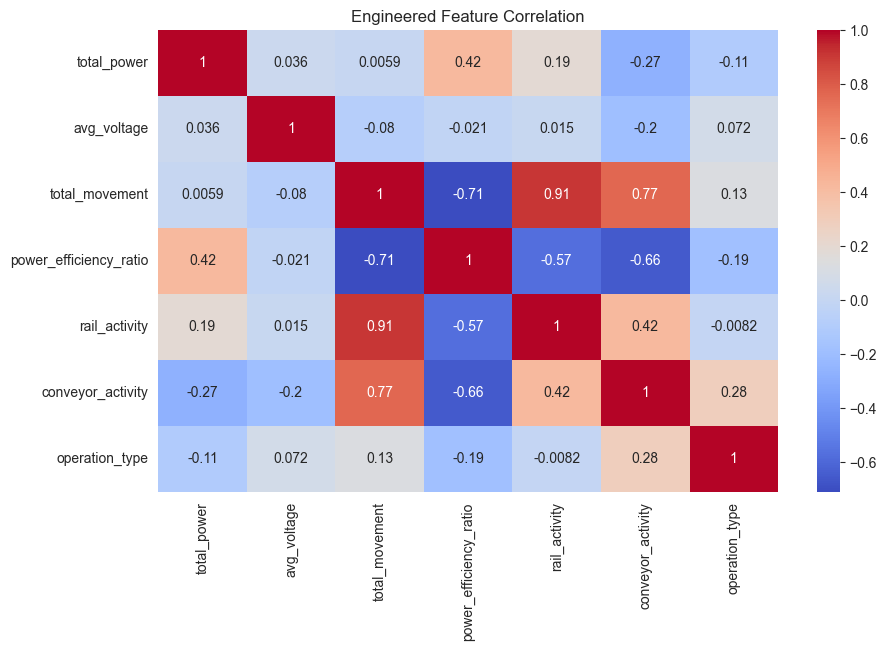

In [ ]:
# ============================================================
# ENGINEERED FEATURE CORRELATION
# ============================================================

corr_features = engineered_features + ["operation_type"]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Engineered Feature Correlation")

plt.show()

<Axes: xlabel='operation_name'>

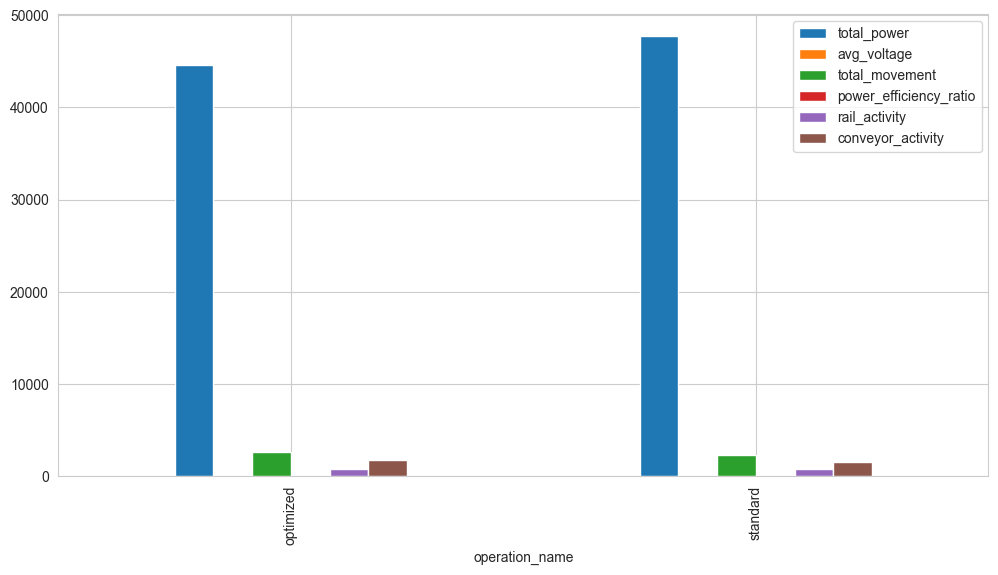

In [ ]:
# ============================================================
# OPERATIONAL INSIGHT EXPLORATION
# ============================================================

operation_summary = df.groupby("operation_name")[engineered_features].mean()

operation_summary.plot(kind="bar", figsize=(12,6))

In [ ]:
# Sesudah (Rekomendasi MLOps):
engineered_df = df.copy()

# Drop kolom leakage sebelum diekspor
if 'operation_name' in engineered_df.columns:
    engineered_df = engineered_df.drop(columns=['operation_name'])

engineered_df.to_csv("../data/processed/hrss_clean_integrated_with_engineered_features.csv", index=False)
print("Engineered dataset saved (leakage-free)!")


NameError: name 'df' is not defined